#### Audio classification data preprocessing

In [1]:
# lets read a sample audio file
import librosa
audio_file_path = r"D:\Coding\DeepLearning\Datasets\UrbanSound8K\24074-1-0-4.wav"
audio_data, sample_rate = librosa.load(audio_file_path)

In [2]:
audio_data

array([-0.02061145, -0.03201887, -0.03072608, ..., -0.01214315,
       -0.0188606 , -0.03248132], shape=(88200,), dtype=float32)

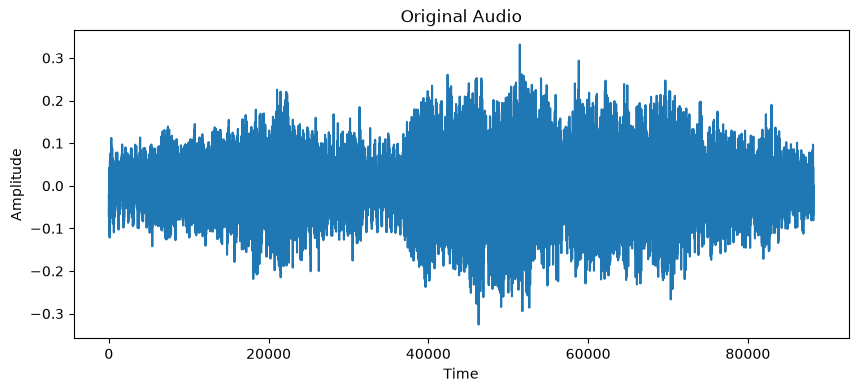

In [4]:
## Lets plot the librosa audio data
import matplotlib.pyplot as plt
#original audio with 1 channel
plt.figure(figsize=(10,4))
plt.plot(audio_data)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Original Audio")
plt.show()

### Observation
Here librosa converts the signal to a mono signal, meaning the channel will always be 1


In [5]:
## lets read with scipy
from scipy.io import wavfile as wav
wave_sample_rate, wave_audio = wav.read(audio_file_path)
wave_audio.shape

(176400, 2)

In [6]:
wave_audio

array([[-1077,  -767],
       [-1119,  -725],
       [-1256,  -700],
       ...,
       [-1222,  -397],
       [-1252,  -722],
       [-1259, -1052]], shape=(176400, 2), dtype=int16)

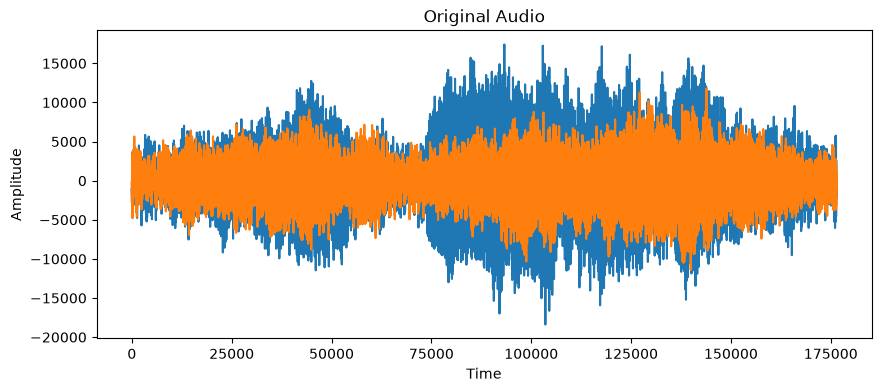

In [7]:
import matplotlib.pyplot as plt
#original audio with 2 channel
plt.figure(figsize=(10,4))
plt.plot(wave_audio)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Original Audio")
plt.show()

### extract features

Here we will be using Mel-Frequency Cepstral Coefficients(MFCC) fromt he audio samples. The MFCC summarizes the frequency distribution across the window size, so it is possible to analyse both the frequency and time characteristics of the sound. these audio representations will allow us to identfy features for classification.

In [8]:
mfcc = librosa.feature.mfcc(y=audio_data, sr=sample_rate, n_mfcc=40)
mfcc.shape

(40, 173)

In [9]:
mfcc

array([[-260.14294  , -248.09836  , -252.69614  , ..., -257.83035  ,
        -252.96143  , -244.77193  ],
       [ 167.64651  ,  165.60715  ,  162.2457   , ...,  173.41843  ,
         163.77637  ,  148.22815  ],
       [ -41.750572 ,  -38.966362 ,  -34.434914 , ...,  -50.27221  ,
         -46.203705 ,  -39.12796  ],
       ...,
       [  -8.577814 ,   -8.295843 ,   -7.943085 , ...,  -10.744289 ,
         -17.186613 ,  -19.697432 ],
       [ -13.960558 ,  -12.552838 ,  -10.111483 , ...,   -8.430209 ,
         -11.161094 ,   -9.142506 ],
       [   9.559399 ,   10.2031975,    7.560831 , ...,   10.85211  ,
          12.680516 ,   13.859481 ]], shape=(40, 173), dtype=float32)

In [11]:
# extracting MFCC for every audio file
import os
import pandas as pd
import librosa

In [12]:
audio_path = r"D:\Coding\DeepLearning\Datasets\UrbanSound8K\audio"
meta_path = r"D:\Coding\DeepLearning\Datasets\UrbanSound8K\metadata\UrbanSound8K.csv"
metadata = pd.read_csv(meta_path)
metadata.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [13]:
def feature_extractor(file_name):
    audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast')
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    mfccsscaled = np.mean(mfccs.T,axis=0)
    return mfccsscaled

In [16]:
import numpy as np
from tqdm import tqdm

In [17]:
# now we will iterate through all the  audio filesand extract the features  
extracted_features = []
for index_num,row in tqdm(metadata.iterrows()):
    file_name = os.path.join(os.path.abspath(audio_path), 'fold'+str(row["fold"])+'/', str(row["slice_file_name"]))
    final_class_labels = row["class"]
    data = feature_extractor(file_name)
    extracted_features.append([data, final_class_labels])

0it [00:00, ?it/s]

3555it [05:58, 10.92it/s]d:\Coding\DeepLearning\audiovenv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
8324it [13:11, 14.08it/s]d:\Coding\DeepLearning\audiovenv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
8327it [13:11, 16.19it/s]d:\Coding\DeepLearning\audiovenv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(
8732it [13:46, 10.56it/s]


In [44]:
extracted_features_df = pd.DataFrame(extracted_features, columns=["feature", "class"])
extracted_features_df.head()

,feature,class
0,"[-217.35526, 70.22339, -130.38527, -53.282898,...",dog_bark
1,"[-424.09818, 109.34077, -52.919525, 60.86475, ...",children_playing
2,"[-458.79114, 121.38419, -46.520657, 52.00812, ...",children_playing
3,"[-413.89984, 101.66371, -35.42945, 53.036358, ...",children_playing
4,"[-446.60352, 113.68541, -52.402214, 60.302044,...",children_playing


In [45]:
X = np.array(extracted_features_df["feature"].tolist())
y = np.array(extracted_features_df["class"].tolist())

In [46]:
X.shape

(8732, 40)

In [47]:
# y = np.array(pd.get_dummies(y))
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = to_categorical(le.fit_transform(y))
y.shape

(8732, 10)

In [59]:
y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(8732, 10))

In [48]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [49]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6985, 40), (1747, 40), (6985, 10), (1747, 10))

In [50]:
import numpy as np
# import tensorflow as tf

print(np.__version__)
# print(tf.__version__)

2.4.6


In [51]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Activation
from tensorflow.keras.optimizers import Adam
from sklearn import metrics

In [52]:
num_lables = y.shape[1]

In [53]:
model = Sequential()
#first layer
model.add(Dense(100, input_shape=(40,), activation='relu'))
model.add(Dropout(0.5))
#second layer
model.add(Dense(200, activation='relu'))
model.add(Dropout(0.5))
#third layer
model.add(Dense(100, activation='relu'))
model.add(Dropout(0.5))
#final layer
model.add(Dense(num_lables, activation='softmax'))

d:\Coding\DeepLearning\audiovenv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [54]:
model.summary()  

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 100)            │         4,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 200)            │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,410 (177.38 KB)

 Trainable params: 45,410 (177.38 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
# Training model
from tensorflow.keras.callbacks import ModelCheckpoint
from datetime import datetime

In [56]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [57]:
num_epochs = 100
num_batch_size = 32

checkpoint = ModelCheckpoint("audio_classification.keras",verbose=1,save_best_only=True)

start = datetime.now()
model.fit(X_train, y_train, batch_size=num_batch_size, epochs=num_epochs, validation_data=(X_test, y_test), callbacks=[checkpoint])

duration = datetime.now() - start
print("Training completed in time: ", duration)

Epoch 1/100
208/219 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1140 - loss: 23.8329
Epoch 1: val_loss improved from None to 2.24983, saving model to audio_classification.keras

Epoch 1: finished saving model to audio_classification.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.1225 - loss: 11.7912 - val_accuracy: 0.1729 - val_loss: 2.2498
Epoch 2/100
214/219 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1375 - loss: 2.8121
Epoch 2: val_loss improved from 2.24983 to 2.24604, saving model to audio_classification.keras

Epoch 2: finished saving model to audio_classification.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1343 - loss: 2.6215 - val_accuracy: 0.1666 - val_loss: 2.2460
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1604 - loss: 2.3777
Epoch 3: val_loss improved from 2.24604 to 2.19537, saving model to audio_classification.keras

Epoch 3: finished saving model to audio_classification.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms

In [60]:
test_accuracy = model.evaluate(X_test, y_test)
print(test_accuracy[1])

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7945 - loss: 0.7040
0.7945048809051514


In [39]:
file_name=r"D:\Coding\DeepLearning\Datasets\UrbanSound8K\24074-1-0-4.wav"

prediction_features = feature_extractor(file_name)
prediction_features = prediction_features.reshape(1, -1)
prediction_features.shape

(1, 40)

In [43]:
predictions = model.predict(prediction_features)
predicted_class = predictions.argmax(axis=1)
print(predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
[1]


### testing new audio data

In [64]:
filename = r"D:\Coding\DeepLearning\Datasets\UrbanSound8K\horn.wav"
audio, sample_rate = librosa.load(filename, res_type='kaiser_fast')
mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
mfccsscaled = np.mean(mfccs.T,axis=0)
mfccsscaled.shape
print(mfccsscaled)
mfccsscaled = mfccsscaled.reshape(1, -1)
print(mfccsscaled)
print(mfccsscaled.shape)
predicted_label = model.predict(mfccsscaled)
predicted_label = predicted_label.argmax(axis=1)
print(predicted_label)
predicted_class = le.inverse_transform(predicted_label)
print(predicted_class)

[-214.19542    148.62698    -54.880013    26.029545     5.352429
    6.07327      7.4283905   27.09772    -17.32833     16.638756
   -4.7728977   -4.346835    -6.864467    15.111316    -0.8350105
   12.53751      6.390059     7.648161     2.7044039    9.44879
   -7.7962203  -11.403353    -6.7084885    4.0722494    4.6648254
   -4.701782    -5.330746    11.378321    14.915439    -1.6279807
  -23.135107   -12.592824    12.094103    16.566788     3.7997673
    4.620814    -2.3210824  -17.365364   -11.174243    13.654798 ]
[[-214.19542    148.62698    -54.880013    26.029545     5.352429
     6.07327      7.4283905   27.09772    -17.32833     16.638756
    -4.7728977   -4.346835    -6.864467    15.111316    -0.8350105
    12.53751      6.390059     7.648161     2.7044039    9.44879
    -7.7962203  -11.403353    -6.7084885    4.0722494    4.6648254
    -4.701782    -5.330746    11.378321    14.915439    -1.6279807
   -23.135107   -12.592824    12.094103    16.566788     3.7997673
     4.620